# Naive Bayes - Continuos values and Discrete values

## Continuos Values

### import libraries required

In [31]:
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns



### load data

In [32]:
data = load_iris()

X = pd.DataFrame(data.data)
y = data.target

X.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### EDA

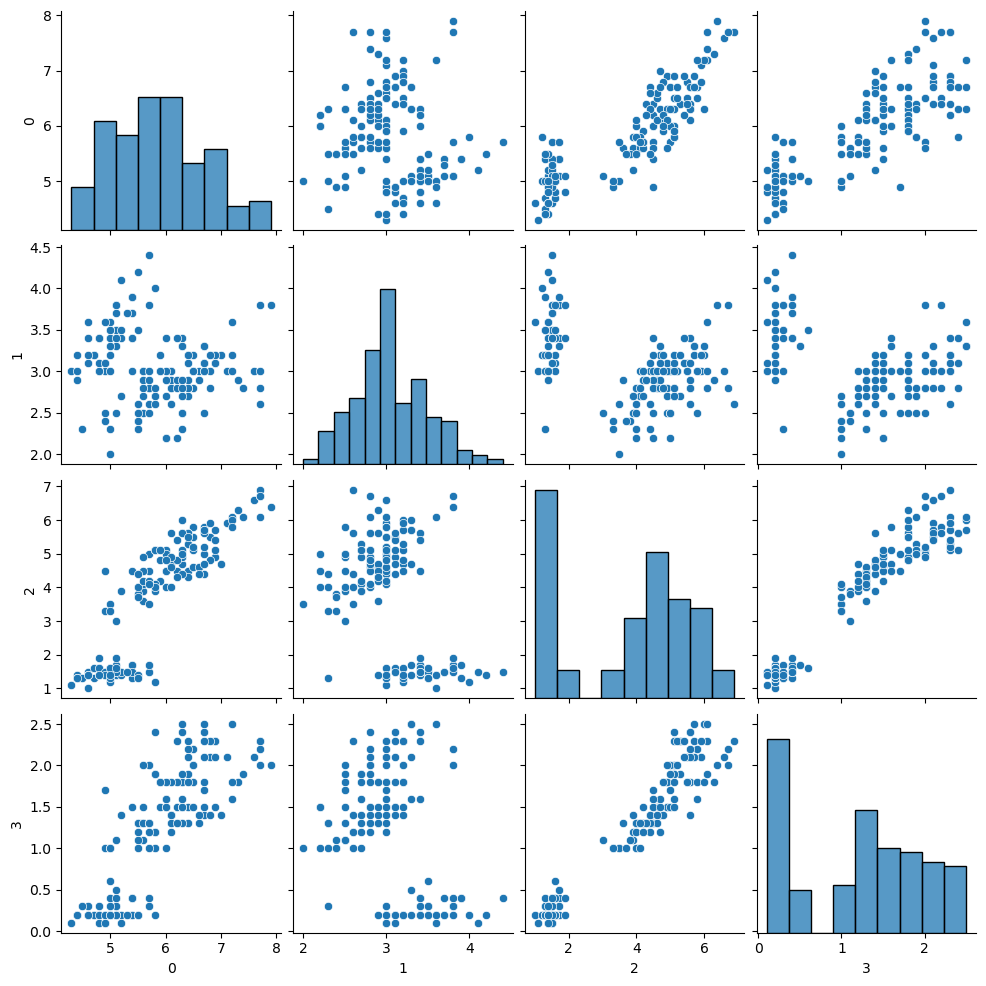

In [33]:
sns.pairplot(X)

### train-test split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

### Train Model and Predict

In [35]:
model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Evaluation

In [36]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("confusion_matrix:", confusion_matrix(y_test, y_pred))
print("classification_report:", classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667
confusion_matrix: [[ 8  0  0]
 [ 0 10  0]
 [ 0  1 11]]
classification_report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.91      1.00      0.95        10
           2       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## Discrete Values

### Data Extraction

In [37]:
import pandas as pd

df = pd.read_csv('spam.csv')
df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


### Rename columns for covenience

In [38]:
df.rename(columns={
    'v1': 'label',
    'v2': 'message'
}, inplace=True)

### Split with Encoding

In [39]:
X = df['message']
y = df['label'].map({'ham': 0, 'spam': 1})

### Remove Stopwords

In [40]:
from nltk.corpus import stopwords

import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['message'] = df['message'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ninga\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Convert text to Numbers

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['message'])

In [42]:
### Train Model and predict with Evaluation

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("confusion_matrix:", confusion_matrix(y_test, y_pred))
print("classification_report:", classification_report(y_test, y_pred))

Accuracy: 0.9605381165919282
confusion_matrix: [[952   0]
 [ 44 119]]
classification_report:               precision    recall  f1-score   support

           0       0.96      1.00      0.98       952
           1       1.00      0.73      0.84       163

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.96      0.96      0.96      1115

